# 230 — Blob clustering

Blob feature extraction → score gating → KMeans (K-sweep) + Hierarchical clustering on the gated, weighted blob feature matrix `Xw`.

Outputs land in `outputs/clustering/{kmeans,hierarchical}/blob/runs/<timestamp>/` via `lf_cluster_run.fit_and_save`.
Each run writes: model.joblib, predictor.joblib, X_train.npy, labels.csv, metrics.json, manifest.json, plus standard figures (centroids, silhouette per cluster, similarity heatmap, centroid distance heatmap).

Per-cluster mean-ERSP thumbnails (`cluster_centroids/cluster_<NN>.png`) are written by the final BACKFILL_CENTROIDS cell so the MOBA cluster-chip thumbnails light up automatically.


In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from functions import lf_blob_clustering_config as cfg
from functions.lf_blob_clustering import (
    s20_build_valley_features,
    s30_gate_by_blob_score,
    q31_plot_score_histograms,
    q32_plot_score_gating_grid,
    q33_plot_valley_overlay_grid,
)
from functions.lf_blob_metrics import s22_build_blob_feature_matrix, s23_init_blob_metric
from functions.lf_clustering import s10_load_ersps
from functions import lf_cluster_run as R

SCRIPT_NAME = '230_blob_clustering.ipynb'


## Config

In [ ]:
# ── data input ───────────────────────────────
INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY')
TASK      = 'LM'
CONDITIONS = ('audio', 'picture', 'reading')
N_FREQ, N_TIME = 129, 300

# ── segmentation ───────────────────────────────
VALLEY_PARAMS = cfg.VALLEY_PARAMS

# ── score gating ───────────────────────────────
BLOB_SCORE_QUANTILE  = cfg.BLOB_SCORE_QUANTILE
MANUAL_SCORE_THR     = None   # set a float to override quantile

# ── feature weighting ───────────────────────────
FEATURE_TYPE_WEIGHTS = cfg.FEATURE_TYPE_WEIGHTS

# ── clustering (orchestrator handles save layout) ──────────────────
# Sweep KMeans across multiple K so silhouette can pick the best.
# Same range as 210 raw clustering for cross-feature-set comparison.
KMEANS_K_RANGE = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

# Hierarchical: single K cut. Keep the same K as the best KMeans K below.
HC_METHOD      = 'average'      # 'average' | 'complete' | 'ward'
HC_METRIC      = 'euclidean'    # only used with non-ward linkages
HC_N_CLUSTERS  = 10             # cut HC at this K (matches mid of KMEANS_K_RANGE)
RANDOM_STATE   = cfg.RANDOM_STATE

print('VALLEY_PARAMS:', VALLEY_PARAMS)
print('BLOB_SCORE_QUANTILE:', BLOB_SCORE_QUANTILE)
print('KMEANS_K_RANGE:', KMEANS_K_RANGE)


## 1 — Load ERSPs

In [3]:
df_meta, ersp_list = s10_load_ersps(
    input_dir=INPUT_DIR,
    task=TASK,
    allowed_conditions=CONDITIONS,
    n_freq=N_FREQ,
    n_time=N_TIME,
)
print(df_meta.shape, len(ersp_list))
df_meta.head()

Detected patient folders:
  - EL030
  - EL035
  - EL036
  - EL037
  - EL038
  - EL040
  - EL042
  - EL043
  - EL045
  - PAT_2868
  - PAT_3066
  - PAT_3301
  - PAT_3390
  - PAT_3415
  - PAT_3455
  - PAT_3780
  - PAT_3965
  - PAT_3975

Total patients detected: 18

Patient EL030 — conditions found: ['audio', 'picture', 'reading']
  Loading 97 files from condition 'audio'
  Loading 97 files from condition 'picture'
  Loading 97 files from condition 'reading'

Patient EL035 — conditions found: ['audio', 'picture', 'reading']
  Loading 115 files from condition 'audio'
  Loading 115 files from condition 'picture'
  Loading 115 files from condition 'reading'

Patient EL036 — conditions found: ['audio', 'picture', 'reading']
  Loading 58 files from condition 'audio'
  Loading 58 files from condition 'picture'
  Loading 58 files from condition 'reading'

Patient EL037 — conditions found: ['audio', 'picture', 'reading']
  Loading 96 files from condition 'audio'
  Loading 96 files from condition '

,sample_idx,patient_id,condition,task,electrode,file_path
0,0,EL030,audio,LM,A_L10,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...
1,1,EL030,audio,LM,A_L11,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...
2,2,EL030,audio,LM,A_L12,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...
3,3,EL030,audio,LM,A_L13,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...
4,4,EL030,audio,LM,A_L14,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...


## 2 — Valley blob segmentation + feature extraction

In [5]:
X_blob, max_scores, blobs_per_sample = s22_build_blob_feature_matrix(
    ersp_list=ersp_list,
    max_blobs=int(VALLEY_PARAMS['max_blobs']),
    thr_pos=float(VALLEY_PARAMS['thr_pos']),
    thr_neg=float(VALLEY_PARAMS['thr_neg']),
    delta_valley=float(VALLEY_PARAMS['delta_valley']),
    min_mean_pos=float(VALLEY_PARAMS['min_mean_pos']),
    max_mean_neg=float(VALLEY_PARAMS['max_mean_neg']),
    sign_mode=str(VALLEY_PARAMS['sign_mode']),
)
print('X_blob:', X_blob.shape)
print('max_scores:', max_scores.shape, '  min/max:', max_scores.min(), max_scores.max())

Valley-blob feature matrix: X_blob.shape=(3602, 48) (max_blobs=6, features_per_blob=8)
X_blob: (3602, 48)
max_scores: (3602,)   min/max: 0.0 53097.812


## 3 — Score gating

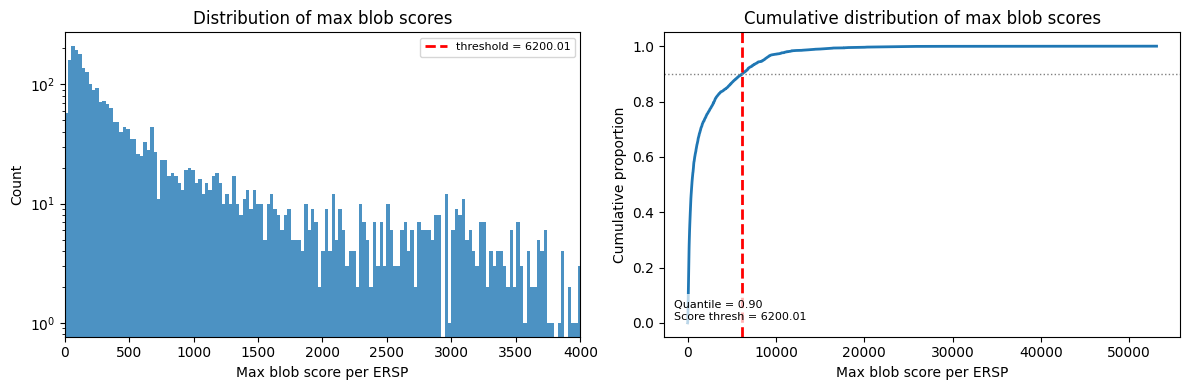

In [6]:
q31_plot_score_histograms(
    max_scores=max_scores,
    score_thresh=float(np.quantile(max_scores, BLOB_SCORE_QUANTILE)),
    quantile=BLOB_SCORE_QUANTILE,
)

In [7]:
(
    df_keep, ersp_keep, X_blob_keep,
    keep_idx, score_thr, keep_mask, drop_idx
) = s30_gate_by_blob_score(
    df_meta=df_meta.copy(),
    ersp_list=ersp_list,
    X_blob=X_blob,
    max_scores=max_scores,
    quantile=BLOB_SCORE_QUANTILE,
    manual_threshold=MANUAL_SCORE_THR,
)
print('Kept:', len(df_keep), '  Dropped:', len(drop_idx))

Score gating:
  quantile=0.90 → q_thresh=6200.008
  using score_thresh=6200.008 (from quantile)
  kept   : 361 ERSPs
  dropped: 3241 ERSPs
Kept: 361   Dropped: 3241


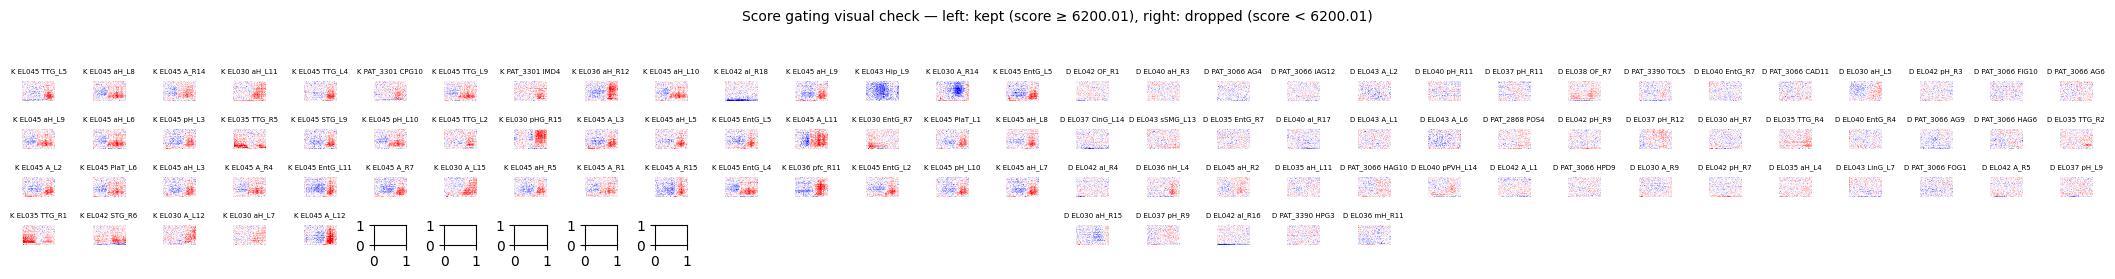

In [8]:
q32_plot_score_gating_grid(
    ersp_list_raw=ersp_list,
    df_meta_raw=df_meta,
    keep_idx=keep_idx,
    drop_idx=drop_idx,
    score_thresh=score_thr,
)

## 4 — Feature weighting

In [9]:
s23_init_blob_metric(
    max_blobs=int(VALLEY_PARAMS['max_blobs']),
    features_per_blob=8,
    feature_type_weights=FEATURE_TYPE_WEIGHTS,
)

# Build weight vector and apply
from functions.lf_blob_metrics import BLOB_WEIGHT_VEC
Xw = X_blob_keep * BLOB_WEIGHT_VEC
print('Xw:', Xw.shape)

[s23_init_blob_metric] 6 blobs × 8 features = 48D; weight_vec.shape=(48,)
Xw: (361, 48)


# Clustering

Two methods on the same `Xw` (weighted blob feature matrix): K-Means (with K sweep) and Hierarchical (Ward / average).
Each `fit_and_save` call writes a self-contained run directory and updates `outputs/clustering/index.json`.


In [ ]:
# KMeans K-sweep on blob features.
manifest_km = R.fit_and_save(
    Xw,
    df_keep=df_keep,
    method='kmeans',
    feature_set='blob',
    params={'k_range': KMEANS_K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    method_label='K-Means',
    feature_set_label='Blob Features',
    notebook=SCRIPT_NAME,
)
BEST_K = manifest_km['summary']['best_k']
print(f'Best K (KMeans/blob, by silhouette): {BEST_K}')


In [ ]:
# Hierarchical on blob features (using HC_METHOD + HC_METRIC + HC_N_CLUSTERS).
manifest_hc = R.fit_and_save(
    Xw,
    df_keep=df_keep,
    method='hierarchical',
    feature_set='blob',
    params={'linkage': HC_METHOD, 'metric': HC_METRIC, 'n_clusters': HC_N_CLUSTERS},
    method_label='Hierarchical',
    feature_set_label='Blob Features',
    notebook=SCRIPT_NAME,
)


## Blob artifacts — needed by 231 minus101 clustering

231 needs to rebuild the same blob segmentation on the same gated samples. The cheapest persistence
is to dump `keep_idx` and `blobs_per_sample` into each blob run dir so 231 can find them via
`outputs/clustering/{kmeans|hierarchical}/blob/runs/<latest>/blob_artifacts/`. These files are gitignored
(joblib + npy), so they live locally on the server but don't pollute the repo.


In [ ]:
# Save blob-specific artifacts so 231 minus101 can reproduce the gating + blob objects.
import joblib
from pathlib import Path

CLUSTERING_DIR = Path(R.DEFAULT_OUTPUTS_ROOT)

def _save_blob_artifacts(manifest):
    run_dir = CLUSTERING_DIR / manifest['method'] / manifest['feature_set'] / 'runs' / manifest['run_id']
    art_dir = run_dir / 'blob_artifacts'
    art_dir.mkdir(parents=True, exist_ok=True)
    np.save(art_dir / 'keep_idx.npy', keep_idx)
    joblib.dump(blobs_per_sample, art_dir / 'blobs_per_sample.joblib')
    # Stash the gating config (so 231 can replay s10 + s22 exactly)
    with open(art_dir / 'gating_config.json', 'w') as f:
        import json as _json
        _json.dump({
            'input_dir': str(INPUT_DIR),
            'task': TASK,
            'conditions': list(CONDITIONS),
            'n_freq': N_FREQ,
            'n_time': N_TIME,
            'valley_params': {k: float(v) if isinstance(v, (int, float, np.floating)) else v
                              for k, v in VALLEY_PARAMS.items()},
            'blob_score_quantile': float(BLOB_SCORE_QUANTILE),
            'manual_score_thr': MANUAL_SCORE_THR,
        }, f, indent=2, default=str)
    print(f'  blob_artifacts -> {art_dir}')

_save_blob_artifacts(manifest_km)
_save_blob_artifacts(manifest_hc)


## Per-cluster centroid PNGs (for the MOBA cluster chips)

Same pattern as 210: walk `index.json`, for every `feature_set == 'blob'` run, compute the mean
ERSP per cluster (using `ersp_keep` in memory — the gated samples used in this notebook) and
write `<run_dir>/cluster_centroids/cluster_<NN>.png`. MOBA picks these up automatically for the
cluster-chip thumbnails.


In [ ]:
# BACKFILL_CENTROIDS — per-cluster mean-ERSP thumbnails for the MOBA chips (blob feature_set).
import json

CLUSTERING_DIR = Path(R.DEFAULT_OUTPUTS_ROOT)
INDEX_PATH = CLUSTERING_DIR / 'index.json'

# Stack the gated ERSPs into a (N, N_FREQ, N_TIME) 3D array for fast mean-by-cluster.
ersp_keep_3d = np.stack(ersp_keep, axis=0) if isinstance(ersp_keep, list) else np.asarray(ersp_keep)
print('ersp_keep_3d:', ersp_keep_3d.shape)

def _save_per_cluster_centroid_pngs_blob(manifest, ersp_3d_local, *, vlim=5.0):
    if manifest['feature_set'] != 'blob':
        return 0
    run_dir = CLUSTERING_DIR / manifest['method'] / manifest['feature_set'] / 'runs' / manifest['run_id']
    df = pd.read_csv(run_dir / 'labels.csv')
    cluster_col = f"cluster_{manifest['method']}_{manifest['feature_set']}"
    if cluster_col not in df.columns:
        cands = [c for c in df.columns if c.startswith('cluster_')]
        if not cands: return 0
        cluster_col = cands[0]
    labels = df[cluster_col].to_numpy()
    if len(labels) != ersp_3d_local.shape[0]:
        print(f"  [skip] {manifest['run_id']}: labels ({len(labels)}) vs ersp_keep ({ersp_3d_local.shape[0]}) mismatch — re-run cells 5–11 in this notebook with the same gating as the run")
        return 0
    out_dir = run_dir / 'cluster_centroids'
    out_dir.mkdir(parents=True, exist_ok=True)
    uniq = sorted(int(c) for c in np.unique(labels))
    # Plot in the same orientation as 210 raw ERSPs: imshow(mean.T, origin='lower')
    for c in uniq:
        idx = np.where(labels == c)[0]
        mean_ersp = ersp_3d_local[idx].mean(axis=0)  # (N_FREQ, N_TIME)
        fig, ax = plt.subplots(figsize=(2, 1.5))
        ax.imshow(mean_ersp, aspect='auto', origin='lower',
                  cmap='bwr', vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        out_path = out_dir / f'cluster_{int(c):02d}.png'
        fig.savefig(out_path, dpi=80, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    return len(uniq)

if not INDEX_PATH.exists():
    print(f'No {INDEX_PATH} yet — run the fit_and_save cells above first.')
else:
    with open(INDEX_PATH) as f:
        idx = json.load(f)
    runs = [r for r in idx.get('runs', []) if r['feature_set'] == 'blob']
    print(f'Backfilling per-cluster centroid PNGs for {len(runs)} blob runs...')
    for run in runs:
        manifest_path = CLUSTERING_DIR / run['path'] / 'manifest.json'
        if not manifest_path.exists():
            print(f"  [skip] {run['path']}: missing manifest.json"); continue
        with open(manifest_path) as f:
            manifest = json.load(f)
        n = _save_per_cluster_centroid_pngs_blob(manifest, ersp_keep_3d)
        if n:
            print(f"  [{manifest['method']}/{manifest['feature_set']}] {manifest['run_id']}  ->  {n} cluster PNGs")
    print('\nDone. Commit and push:')
    print('  git add 02_FBM_Clustering/outputs/clustering')
    print('  git commit -m "Per-cluster centroid PNGs for MOBA chips (blob)"')
    print('  git push')
